- 하단의 코드는 CoLA&EDM workshop 중 구글 코랩에서 사이킷런을 설명하며 raw coding할 때 사용했던 코드임 
- 수업에 사용된 메인 코드의 정리본은 다음 주소에 있음: https://colab.research.google.com/drive/1CwrJZz48FOWksn6X6t41MUCJA0qiVFv6?usp=sharing

In [1]:
import pandas as pd
import numpy as np
from google.colab import files

upload = files.upload()

Saving HR-Employee-Attrition.csv to HR-Employee-Attrition.csv


In [2]:
df = pd.read_csv('HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4.0,Single,5993,19479,8,Y,Yes,11,3,1.0,80,0,8,0,NaN,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2.0,Married,5130,24907,1,Y,No,23,4,4.0,80,1,10,3,3.0,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3.0,Single,2090,2396,6,Y,Yes,15,3,2.0,80,0,7,3,3.0,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3.0,Married,2909,23159,1,Y,Yes,11,3,3.0,80,0,8,3,3.0,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2.0,Married,3468,16632,9,Y,No,12,3,4.0,80,1,6,3,3.0,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   DailyRate                 1470 non-null   int64  
 4   Department                1470 non-null   object 
 5   DistanceFromHome          1470 non-null   int64  
 6   Education                 1470 non-null   int64  
 7   EducationField            1470 non-null   object 
 8   EmployeeCount             1470 non-null   int64  
 9   EmployeeNumber            1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [6]:
df.describe().T.style.background_gradient(subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
Age,1470.000000,36.923810,9.135373,18.000000,30.000000,36.000000,43.000000,60.000000
DailyRate,1470.000000,802.485714,403.509100,102.000000,465.000000,802.000000,1157.000000,1499.000000
DistanceFromHome,1470.000000,9.192517,8.106864,1.000000,2.000000,7.000000,14.000000,29.000000
Education,1470.000000,2.912925,1.024165,1.000000,2.000000,3.000000,4.000000,5.000000
EmployeeCount,1470.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
EmployeeNumber,1470.000000,1024.865306,602.024335,1.000000,491.250000,1020.500000,1555.750000,2068.000000
EnvironmentSatisfaction,1470.000000,2.721769,1.093082,1.000000,2.000000,3.000000,4.000000,4.000000
HourlyRate,1470.000000,65.891156,20.329428,30.000000,48.000000,66.000000,83.750000,100.000000
JobInvolvement,1470.000000,2.729932,0.711561,1.000000,2.000000,3.000000,3.000000,4.000000
JobLevel,1470.000000,2.063946,1.106940,1.000000,1.000000,2.000000,3.000000,5.000000


In [10]:
# df.drop(columns=['EmployeeCount', 'StandardHours'], inplace=True)
df.shape

(1470, 33)

In [11]:
df.isnull().sum()

Age                          0
Attrition                    0
BusinessTravel               0
DailyRate                    0
Department                   0
DistanceFromHome             0
Education                    0
EducationField               0
EmployeeNumber               0
EnvironmentSatisfaction      0
Gender                       0
HourlyRate                   0
JobInvolvement               0
JobLevel                     0
JobRole                      0
JobSatisfaction             15
MaritalStatus                0
MonthlyIncome                0
MonthlyRate                  0
NumCompaniesWorked           0
Over18                       0
OverTime                     0
PercentSalaryHike            0
PerformanceRating            0
RelationshipSatisfaction    15
StockOptionLevel             0
TotalWorkingYears            0
TrainingTimesLastYear        0
WorkLifeBalance              6
YearsAtCompany               0
YearsInCurrentRole           0
YearsSinceLastPromotion      0
YearsWit

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f40f9d83ed0>,
      dtype=object)

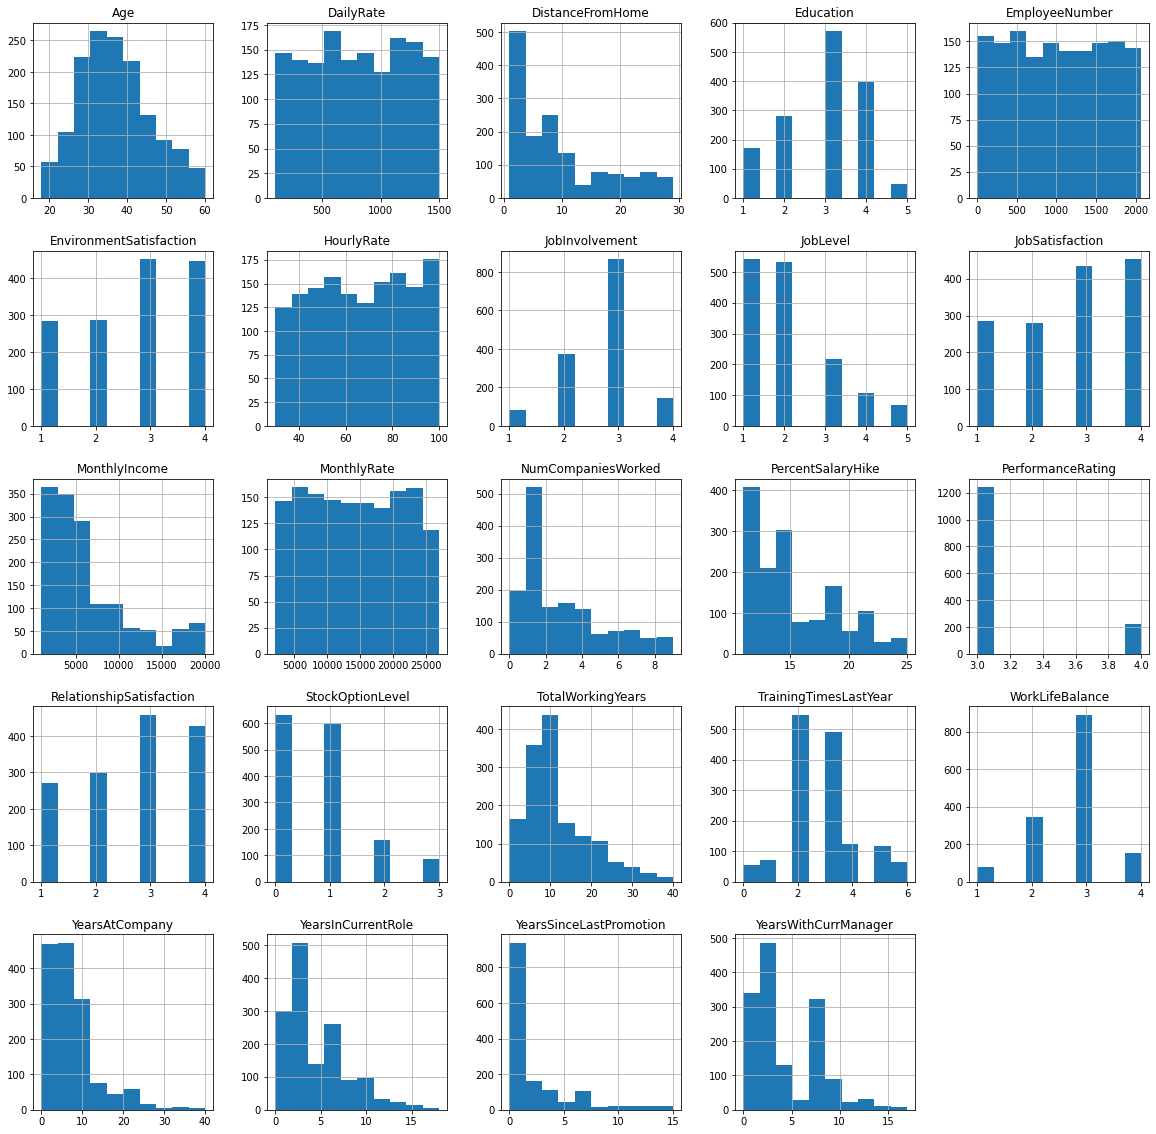

In [12]:
df.hist(figsize=(20,20))

In [15]:
cat_col =[]
num_col =[]

for column in df.columns.tolist():
  if df[column].dtypes == object:
    cat_col.append(column)
  else:
    num_col.append(column)

In [16]:
cat_col

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

In [17]:
num_col

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [18]:
df_nu = df[num_col]
df_cat = df[cat_col]

print(df_nu.shape,
      df_cat.shape)

(1470, 24) (1470, 9)


In [19]:
df_nu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   DailyRate                 1470 non-null   int64  
 2   DistanceFromHome          1470 non-null   int64  
 3   Education                 1470 non-null   int64  
 4   EmployeeNumber            1470 non-null   int64  
 5   EnvironmentSatisfaction   1470 non-null   int64  
 6   HourlyRate                1470 non-null   int64  
 7   JobInvolvement            1470 non-null   int64  
 8   JobLevel                  1470 non-null   int64  
 9   JobSatisfaction           1455 non-null   float64
 10  MonthlyIncome             1470 non-null   int64  
 11  MonthlyRate               1470 non-null   int64  
 12  NumCompaniesWorked        1470 non-null   int64  
 13  PercentSalaryHike         1470 non-null   int64  
 14  Performa

In [25]:
from sklearn.impute import SimpleImputer

imp =SimpleImputer(missing_values=np.nan,
                   strategy='mean')
imp.fit(df_nu)
array_nu = imp.transform(df_nu)
df_nu = pd.DataFrame(array_nu, columns=df_nu.columns, index = df_nu.index)
df_nu

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,1102.0,1.0,2.0,1.0,2.0,94.0,3.0,2.0,4.0,5993.0,19479.0,8.0,11.0,3.0,1.0,0.0,8.0,0.0,2.763661,6.0,4.0,0.0,5.0
1,49.0,279.0,8.0,1.0,2.0,3.0,61.0,2.0,2.0,2.0,5130.0,24907.0,1.0,23.0,4.0,4.0,1.0,10.0,3.0,3.000000,10.0,7.0,1.0,7.0
2,37.0,1373.0,2.0,2.0,4.0,4.0,92.0,2.0,1.0,3.0,2090.0,2396.0,6.0,15.0,3.0,2.0,0.0,7.0,3.0,3.000000,0.0,0.0,0.0,0.0
3,33.0,1392.0,3.0,4.0,5.0,4.0,56.0,3.0,1.0,3.0,2909.0,23159.0,1.0,11.0,3.0,3.0,0.0,8.0,3.0,3.000000,8.0,7.0,3.0,0.0
4,27.0,591.0,2.0,1.0,7.0,1.0,40.0,3.0,1.0,2.0,3468.0,16632.0,9.0,12.0,3.0,4.0,1.0,6.0,3.0,3.000000,2.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36.0,884.0,23.0,2.0,2061.0,3.0,41.0,4.0,2.0,4.0,2571.0,12290.0,4.0,17.0,3.0,3.0,1.0,17.0,3.0,3.000000,5.0,2.0,0.0,3.0
1466,39.0,613.0,6.0,1.0,2062.0,4.0,42.0,2.0,3.0,1.0,9991.0,21457.0,4.0,15.0,3.0,1.0,1.0,9.0,5.0,3.000000,7.0,7.0,1.0,7.0
1467,27.0,155.0,4.0,3.0,2064.0,2.0,87.0,4.0,2.0,2.0,6142.0,5174.0,1.0,20.0,4.0,2.0,1.0,6.0,0.0,3.000000,6.0,2.0,0.0,3.0
1468,49.0,1023.0,2.0,3.0,2065.0,4.0,63.0,2.0,2.0,2.0,5390.0,13243.0,2.0,14.0,3.0,4.0,0.0,17.0,3.0,2.000000,9.0,6.0,0.0,8.0


In [26]:
df_nu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   float64
 1   DailyRate                 1470 non-null   float64
 2   DistanceFromHome          1470 non-null   float64
 3   Education                 1470 non-null   float64
 4   EmployeeNumber            1470 non-null   float64
 5   EnvironmentSatisfaction   1470 non-null   float64
 6   HourlyRate                1470 non-null   float64
 7   JobInvolvement            1470 non-null   float64
 8   JobLevel                  1470 non-null   float64
 9   JobSatisfaction           1470 non-null   float64
 10  MonthlyIncome             1470 non-null   float64
 11  MonthlyRate               1470 non-null   float64
 12  NumCompaniesWorked        1470 non-null   float64
 13  PercentSalaryHike         1470 non-null   float64
 14  Performa

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(df_nu)

array_nu = scaler.transform(df_nu)
df_nu = pd.DataFrame(array_nu, columns=df_nu.columns, index=df_nu.index)
df_nu

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0.446350,0.742527,-1.010909,-0.891688,-1.701283,-0.660531,1.383138,0.379672,-0.057788,1.160412,-0.108350,0.726020,2.125136,-1.150554,-0.426230,-1.597087,-0.932014,-0.421642,-2.171982,0.000000,-0.164613,-0.063296,-0.679146,0.245834
1,1.322365,-1.297775,-0.147150,-1.868426,-1.699621,0.254625,-0.240677,-1.026167,-0.057788,-0.662914,-0.291719,1.488876,-0.678049,2.129306,2.346151,1.197015,0.241988,-0.164511,0.155707,0.336246,0.488508,0.764998,-0.368715,0.806541
2,0.008343,1.414363,-0.887515,-0.891688,-1.696298,1.169781,1.284725,-1.026167,-0.961486,0.248749,-0.937654,-1.674841,1.324226,-0.057267,-0.426230,-0.665719,-0.932014,-0.550208,0.155707,0.336246,-1.144294,-1.167687,-0.679146,-1.155935
3,-0.429664,1.461466,-0.764121,1.061787,-1.694636,1.169781,-0.486709,0.379672,-0.961486,0.248749,-0.763634,1.243211,-0.678049,-1.150554,-0.426230,0.265648,-0.932014,-0.421642,0.155707,0.336246,0.161947,0.764998,0.252146,-1.155935
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.691313,-1.575686,-1.274014,0.379672,-0.961486,-0.662914,-0.644858,0.325900,2.525591,-0.877232,-0.426230,1.197015,0.241988,-0.678774,0.155707,0.336246,-0.817734,-0.615492,-0.058285,-0.595227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,-0.101159,0.202082,1.703764,-0.891688,1.721670,0.254625,-1.224807,1.785511,-0.057788,1.160412,-0.835451,-0.284329,0.523316,0.489376,-0.426230,0.265648,0.241988,0.735447,0.155707,0.336246,-0.327893,-0.615492,-0.679146,-0.314873
1466,0.227347,-0.469754,-0.393938,-1.868426,1.723332,1.169781,-1.175601,-1.026167,0.845911,-1.574577,0.741140,1.004010,0.523316,-0.057267,-0.426230,-1.597087,0.241988,-0.293077,1.707500,0.336246,-0.001333,0.764998,-0.368715,0.806541
1467,-1.086676,-1.605183,-0.640727,0.085049,1.726655,-0.660531,1.038693,1.785511,-0.057788,-0.662914,-0.076690,-1.284418,-0.678049,1.309341,2.346151,-0.665719,0.241988,-0.678774,-2.171982,0.336246,-0.164613,-0.615492,-0.679146,-0.314873
1468,1.322365,0.546677,-0.887515,0.085049,1.728317,1.169781,-0.142264,-1.026167,-0.057788,-0.662914,-0.236474,-0.150393,-0.277594,-0.330589,-0.426230,1.197015,-0.932014,0.735447,0.155707,-1.086484,0.325228,0.488900,-0.679146,1.086895


In [30]:
df_cat

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Y,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,Y,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Y,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Y,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
...,...,...,...,...,...,...,...,...,...
1465,No,Travel_Frequently,Research & Development,Medical,Male,Laboratory Technician,Married,Y,No
1466,No,Travel_Rarely,Research & Development,Medical,Male,Healthcare Representative,Married,Y,No
1467,No,Travel_Rarely,Research & Development,Life Sciences,Male,Manufacturing Director,Married,Y,Yes
1468,No,Travel_Frequently,Sales,Medical,Male,Sales Executive,Married,Y,No


In [32]:
from sklearn.preprocessing import OrdinalEncoder

ord = OrdinalEncoder()

ord.fit(df_cat)
temp = ord.transform(df_cat)
df_cat = pd.DataFrame(temp, columns=df_cat.columns, index = df_cat.index)
df_cat

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
0,1.0,2.0,2.0,1.0,0.0,7.0,2.0,0.0,1.0
1,0.0,1.0,1.0,1.0,1.0,6.0,1.0,0.0,0.0
2,1.0,2.0,1.0,4.0,1.0,2.0,2.0,0.0,1.0
3,0.0,1.0,1.0,1.0,0.0,6.0,1.0,0.0,1.0
4,0.0,2.0,1.0,3.0,1.0,2.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1465,0.0,1.0,1.0,3.0,1.0,2.0,1.0,0.0,0.0
1466,0.0,2.0,1.0,3.0,1.0,0.0,1.0,0.0,0.0
1467,0.0,2.0,1.0,1.0,1.0,4.0,1.0,0.0,1.0
1468,0.0,1.0,2.0,3.0,1.0,7.0,1.0,0.0,0.0


In [37]:
df_cat =df[cat_col]
df_cat

for col in df_cat.columns.tolist():
  print(df_cat[col].value_counts(), '\n\n')

# from sklearn.preprocessing import OrdinalEncoder

# ord = OrdinalEncoder()

# ord.fit(df_cat)
# temp = ord.transform(df_cat)
# df_cat = pd.DataFrame(temp, columns=df_cat.columns, index = df_cat.index)
# df_cat


  

No     1233
Yes     237
Name: Attrition, dtype: int64 


Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: BusinessTravel, dtype: int64 


Research & Development    961
Sales                     446
Human Resources            63
Name: Department, dtype: int64 


Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: EducationField, dtype: int64 


Male      882
Female    588
Name: Gender, dtype: int64 


Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: JobRole, dtype: int64 


Married     673
Single      470
Divorced    327
Name: MaritalStatus, dtype: int64 


Y    1470
Name: Over18, dtype: int64 


No     105

In [38]:
df_cat.drop(columns=['Over18'], inplace=True)
cat_col.remove('Over18')
df_cat.shape

/usr/local/lib/python3.7/dist-packages/pandas/core/frame.py:4174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


(1470, 8)

In [39]:
from sklearn.preprocessing import OrdinalEncoder

ord = OrdinalEncoder()

ord.fit(df_cat)
temp = ord.transform(df_cat)
df_cat = pd.DataFrame(temp, columns=df_cat.columns, index = df_cat.index)
df_cat

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
0,1.0,2.0,2.0,1.0,0.0,7.0,2.0,1.0
1,0.0,1.0,1.0,1.0,1.0,6.0,1.0,0.0
2,1.0,2.0,1.0,4.0,1.0,2.0,2.0,1.0
3,0.0,1.0,1.0,1.0,0.0,6.0,1.0,1.0
4,0.0,2.0,1.0,3.0,1.0,2.0,1.0,0.0
...,...,...,...,...,...,...,...,...
1465,0.0,1.0,1.0,3.0,1.0,2.0,1.0,0.0
1466,0.0,2.0,1.0,3.0,1.0,0.0,1.0,0.0
1467,0.0,2.0,1.0,1.0,1.0,4.0,1.0,1.0
1468,0.0,1.0,2.0,3.0,1.0,7.0,1.0,0.0


In [40]:
df = pd.concat([df_nu, df_cat], axis=1) # 1 서있음
df

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
0,0.446350,0.742527,-1.010909,-0.891688,-1.701283,-0.660531,1.383138,0.379672,-0.057788,1.160412,-0.108350,0.726020,2.125136,-1.150554,-0.426230,-1.597087,-0.932014,-0.421642,-2.171982,0.000000,-0.164613,-0.063296,-0.679146,0.245834,1.0,2.0,2.0,1.0,0.0,7.0,2.0,1.0
1,1.322365,-1.297775,-0.147150,-1.868426,-1.699621,0.254625,-0.240677,-1.026167,-0.057788,-0.662914,-0.291719,1.488876,-0.678049,2.129306,2.346151,1.197015,0.241988,-0.164511,0.155707,0.336246,0.488508,0.764998,-0.368715,0.806541,0.0,1.0,1.0,1.0,1.0,6.0,1.0,0.0
2,0.008343,1.414363,-0.887515,-0.891688,-1.696298,1.169781,1.284725,-1.026167,-0.961486,0.248749,-0.937654,-1.674841,1.324226,-0.057267,-0.426230,-0.665719,-0.932014,-0.550208,0.155707,0.336246,-1.144294,-1.167687,-0.679146,-1.155935,1.0,2.0,1.0,4.0,1.0,2.0,2.0,1.0
3,-0.429664,1.461466,-0.764121,1.061787,-1.694636,1.169781,-0.486709,0.379672,-0.961486,0.248749,-0.763634,1.243211,-0.678049,-1.150554,-0.426230,0.265648,-0.932014,-0.421642,0.155707,0.336246,0.161947,0.764998,0.252146,-1.155935,0.0,1.0,1.0,1.0,0.0,6.0,1.0,1.0
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.691313,-1.575686,-1.274014,0.379672,-0.961486,-0.662914,-0.644858,0.325900,2.525591,-0.877232,-0.426230,1.197015,0.241988,-0.678774,0.155707,0.336246,-0.817734,-0.615492,-0.058285,-0.595227,0.0,2.0,1.0,3.0,1.0,2.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,-0.101159,0.202082,1.703764,-0.891688,1.721670,0.254625,-1.224807,1.785511,-0.057788,1.160412,-0.835451,-0.284329,0.523316,0.489376,-0.426230,0.265648,0.241988,0.735447,0.155707,0.336246,-0.327893,-0.615492,-0.679146,-0.314873,0.0,1.0,1.0,3.0,1.0,2.0,1.0,0.0
1466,0.227347,-0.469754,-0.393938,-1.868426,1.723332,1.169781,-1.175601,-1.026167,0.845911,-1.574577,0.741140,1.004010,0.523316,-0.057267,-0.426230,-1.597087,0.241988,-0.293077,1.707500,0.336246,-0.001333,0.764998,-0.368715,0.806541,0.0,2.0,1.0,3.0,1.0,0.0,1.0,0.0
1467,-1.086676,-1.605183,-0.640727,0.085049,1.726655,-0.660531,1.038693,1.785511,-0.057788,-0.662914,-0.076690,-1.284418,-0.678049,1.309341,2.346151,-0.665719,0.241988,-0.678774,-2.171982,0.336246,-0.164613,-0.615492,-0.679146,-0.314873,0.0,2.0,1.0,1.0,1.0,4.0,1.0,1.0
1468,1.322365,0.546677,-0.887515,0.085049,1.728317,1.169781,-0.142264,-1.026167,-0.057788,-0.662914,-0.236474,-0.150393,-0.277594,-0.330589,-0.426230,1.197015,-0.932014,0.735447,0.155707,-1.086484,0.325228,0.488900,-0.679146,1.086895,0.0,1.0,2.0,3.0,1.0,7.0,1.0,0.0


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f40e5d989d0>,
      dtype=object)

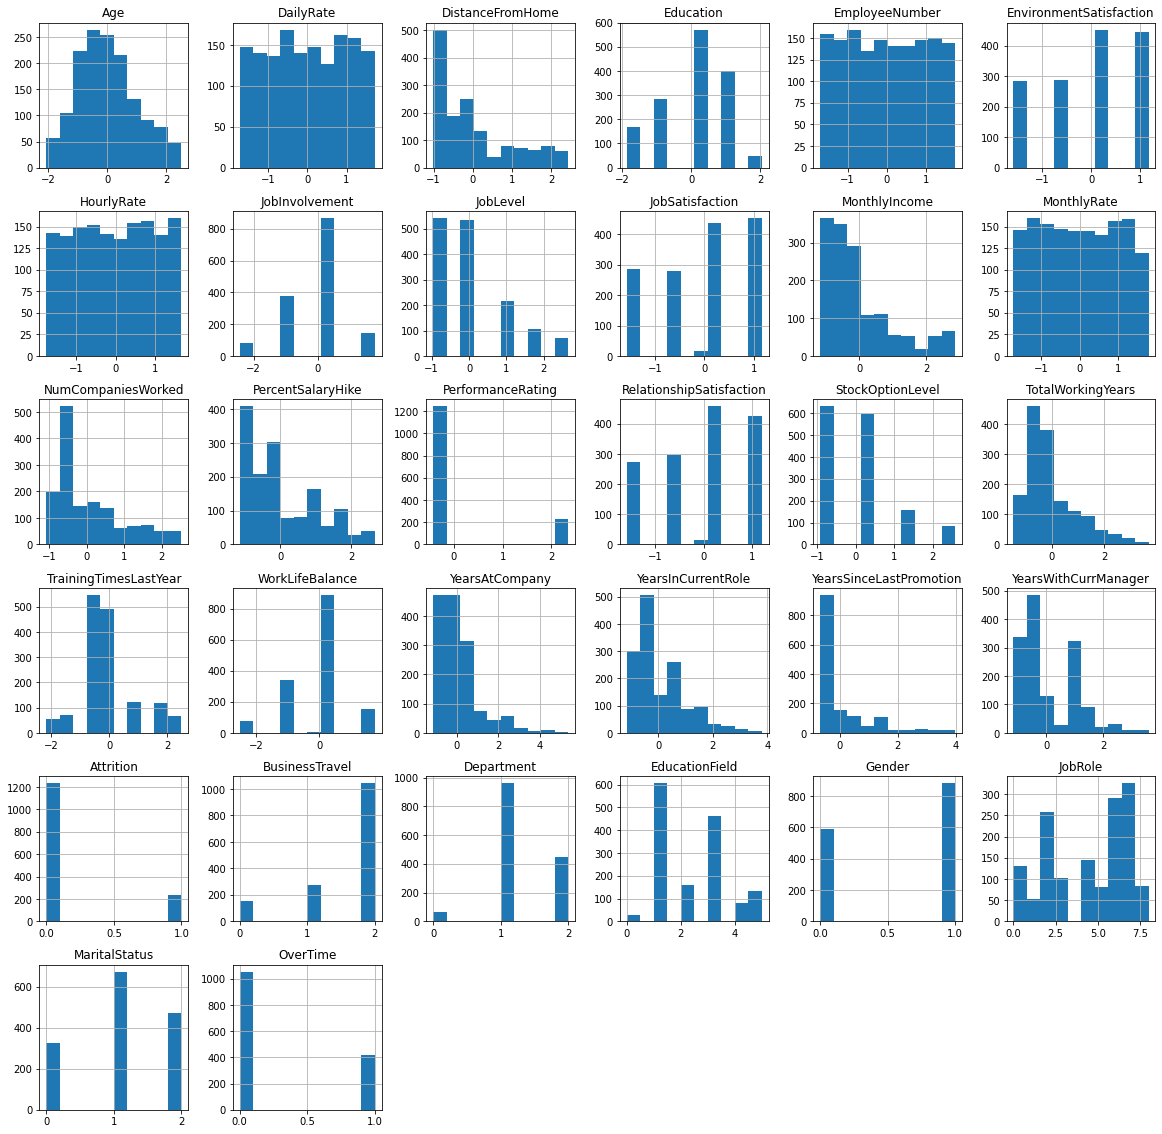

In [41]:
df.hist(figsize=(20,20))

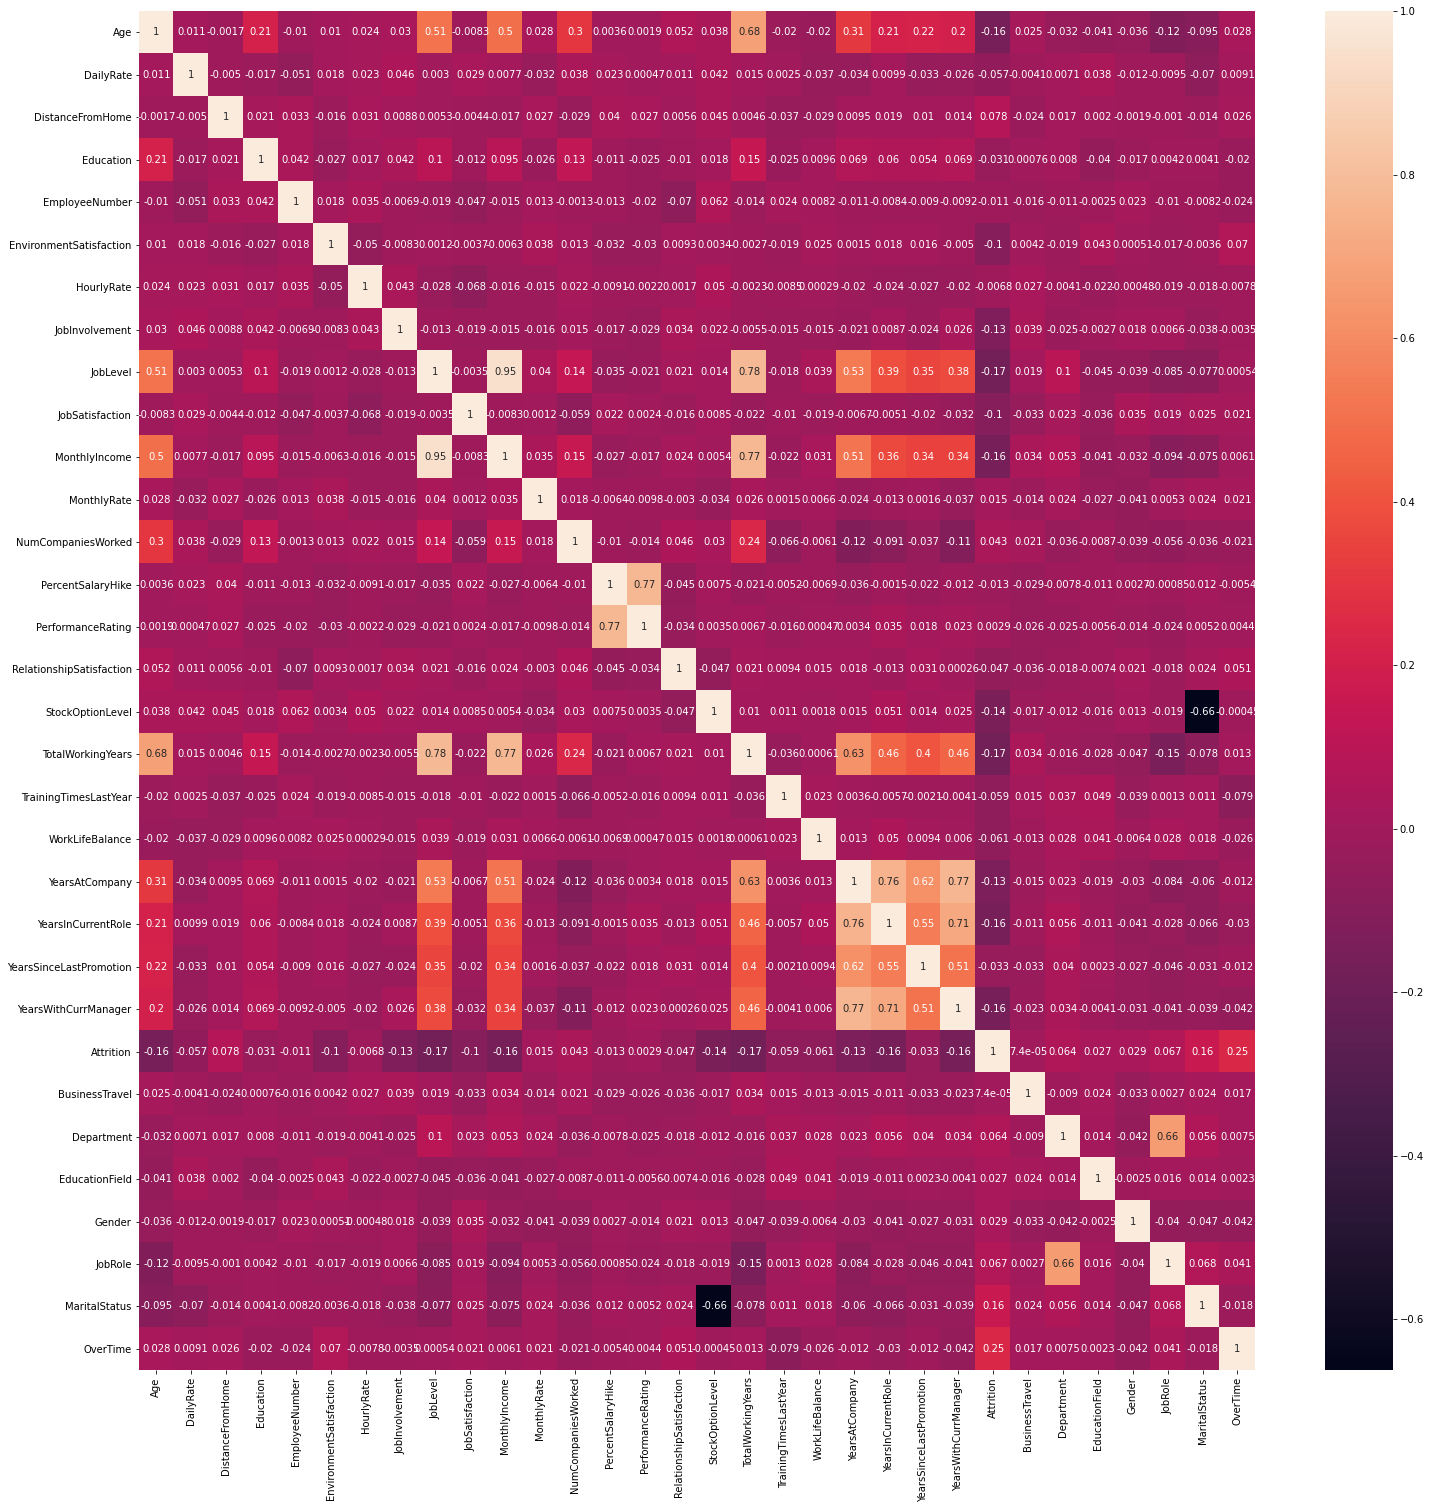

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(25,25))
sns.heatmap(df.corr(), annot=True)

In [46]:
# df

from sklearn.model_selection import train_test_split

feature = df.columns.tolist()
feature.remove('Attrition')
target =['Attrition']

X = df[feature]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.3,
                                                    stratify = y)


In [47]:
print(X_train.shape,
      X_test.shape)

(1029, 31) (441, 31)


In [48]:
X_train

,Age,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
787,1.979376,0.715256,-0.887515,-1.868426,0.118199,1.169781,-0.043851,0.379672,0.845911,-0.662914,0.950432,0.210797,0.122861,0.762698,-0.426230,-0.665719,0.241988,1.506840,0.931603,0.336246,-0.654454,-0.615492,-0.368715,-0.595227,1.0,1.0,1.0,1.0,4.0,1.0,0.0
810,0.993860,-0.982929,-0.764121,-1.868426,0.164725,-1.575686,-0.683535,0.379672,1.749610,0.248749,2.329206,0.180299,0.122861,-0.877232,-0.426230,1.197015,0.241988,1.506840,0.155707,0.336246,0.815068,1.317193,0.562576,1.367249,2.0,2.0,2.0,1.0,3.0,1.0,0.0
1419,0.555852,-0.608584,1.086793,1.061787,1.616988,1.169781,-1.520046,0.379672,-0.057788,-1.574577,-0.232225,-0.439064,1.324226,0.489376,-0.426230,0.265648,0.241988,-0.293077,0.155707,-1.086484,-0.491174,-0.339394,-0.368715,-0.595227,2.0,1.0,1.0,1.0,6.0,0.0,1.0
402,-0.758170,0.692944,0.346427,0.085049,-0.817297,-0.660531,0.841867,0.379672,-0.057788,0.248749,0.015738,0.737123,-1.078504,-1.150554,-0.426230,-0.665719,-0.932014,-0.678774,2.483396,0.336246,-0.327893,-0.063296,0.562576,-0.034520,2.0,2.0,5.0,0.0,7.0,2.0,0.0
317,1.650871,-0.197053,-0.147150,1.061787,-0.983460,0.254625,0.940280,-1.026167,-0.057788,-0.662914,-0.331877,0.482603,-0.277594,-0.057267,-0.426230,-1.597087,-0.932014,-0.035946,0.155707,-1.086484,0.161947,-0.615492,1.493867,0.806541,2.0,1.0,3.0,1.0,6.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1083,0.336849,-0.313571,-0.023755,1.061787,0.845992,1.169781,0.989486,0.379672,-0.961486,-1.574577,-0.952952,1.056572,0.122861,-0.330589,-0.426230,-0.665719,-0.932014,0.478316,0.155707,-2.509214,-0.327893,-0.063296,-0.368715,-1.155935,2.0,1.0,1.0,1.0,2.0,2.0,0.0
25,1.760373,1.188765,-0.517332,0.085049,-1.649772,0.254625,-0.388296,0.379672,2.653309,0.248749,2.675333,-0.502870,0.523316,-1.150554,-0.426230,1.197015,0.241988,1.892537,0.155707,-1.086484,1.141629,2.421585,0.562576,1.086895,2.0,1.0,4.0,0.0,3.0,0.0,0.0
845,0.336849,0.246706,2.073946,-0.891688,0.257776,0.254625,1.284725,-1.026167,-0.057788,1.160412,-0.442153,0.968313,0.122861,-0.603911,-0.426230,1.197015,0.241988,0.606882,0.155707,-2.509214,-0.981014,-0.891589,-0.679146,-1.155935,1.0,1.0,3.0,0.0,6.0,1.0,1.0
1313,-0.867672,-1.121758,0.469821,0.085049,1.361097,-1.575686,-0.486709,-1.026167,-0.961486,-1.574577,-0.885596,-1.567889,0.523316,-0.057267,-0.426230,1.197015,2.589994,-0.935905,0.155707,0.336246,-0.817734,-0.615492,-0.058285,-1.155935,2.0,0.0,0.0,1.0,1.0,0.0,1.0


In [49]:
y_train

,Attrition
787,0.0
810,0.0
1419,0.0
402,0.0
317,1.0
...,...
1083,1.0
25,0.0
845,0.0
1313,1.0


In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

prediction = clf.predict(X_test)

print('훈련결과', clf.score(X_train, y_train).round(3), 
      '시험결과', accuracy_score(y_test, prediction).round(3))

훈련결과 1.0 시험결과 0.755


In [55]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier()
clf.fit(X_train, y_train.values.ravel())

prediction = clf.predict(X_test) 

print('훈련결과', clf.score(X_train, y_train).round(3), 
      '시험결과', accuracy_score(y_test, prediction).round(3))

훈련결과 0.872 시험결과 0.844


In [56]:
from sklearn.svm import SVC

clf = SVC()
clf.fit(X_train, y_train.values.ravel())

prediction = clf.predict(X_test) 

print('훈련결과', clf.score(X_train, y_train).round(3), 
      '시험결과', accuracy_score(y_test, prediction).round(3))

훈련결과 0.857 시험결과 0.841


In [60]:
from sklearn.model_selection import GridSearchCV

parm = {'max_depth': list(range(1, 20, 2)),
        'min_samples_leaf': list(range(1, 20, 2))}

clf = GridSearchCV(DecisionTreeClassifier(), 
                  parm,
                  cv = 5
                  )
clf.fit(X_train, y_train)

clf.best_params_

{'max_depth': 3, 'min_samples_leaf': 13}

In [62]:
prediction = clf.predict(X_test)
print('훈련결과', clf.score(X_train, y_train).round(3), 
      '시험결과', accuracy_score(y_test, prediction).round(3))

훈련결과 0.865 시험결과 0.841


In [64]:
from sklearn.model_selection import GridSearchCV

model_dict = {'의사결정나무': DecisionTreeClassifier(),
            'KNN': KNeighborsClassifier(),
            'SVM': SVC()}

parm_DT = {'max_depth': list(range(1, 20, 2)),
        'min_samples_leaf': list(range(1, 20, 2))}

parm_KNN = {'n_neighbors': list(range(1, 20, 2))}
parm_SVC = {'C': [0.001, 0.01, 0.1, 1, 5, 10, 50]}
parm_ls = [parm_DT, parm_KNN, parm_SVC]


for (model_id, model), parm in zip(model_dict.items(), parm_ls): 
  clf = GridSearchCV(model, 
                    parm,
                    cv = 5
                    )
  clf.fit(X_train, y_train.values.ravel())


  prediction = clf.predict(X_test)
  print(f'{model_id}'
      , clf.best_params_
      ,'훈련결과', clf.score(X_train, y_train).round(3), 
        '시험결과', accuracy_score(y_test, prediction).round(3))

의사결정나무 {'max_depth': 3, 'min_samples_leaf': 13} 훈련결과 0.865 시험결과 0.841
KNN {'n_neighbors': 13} 훈련결과 0.848 시험결과 0.837
SVM {'C': 5} 훈련결과 0.955 시험결과 0.859
